In [2]:
import os
import random
import copy
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import open_clip
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print(torch.cuda.is_available())

cuda
True


In [4]:
DATA_ROOT = Path(r"C:\Users\artem\Downloads\cv lab\confirmed_fronts")

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
EPOCHS_FINETUNE = 6
EPOCHS_SCRATCH = 10
LR_FINETUNE = 1e-4
LR_SCRATCH = 1e-3
WEIGHT_DECAY = 1e-4
MIN_SAMPLES_PER_CLASS = 30

In [5]:
def parse_color_from_filename(filename):
    parts = filename.split("$$")
    if len(parts) < 4:
        return None
    return parts[3].strip()

def collect_dataset(data_root):
    rows = []

    for brand_dir in data_root.iterdir():
        if not brand_dir.is_dir():
            continue

        for year_dir in brand_dir.iterdir():
            if not year_dir.is_dir():
                continue

            for image_path in year_dir.glob("*.jpg"):
                color = parse_color_from_filename(image_path.name)
                if color is None:
                    continue

                rows.append({
                    "path": str(image_path),
                    "brand": brand_dir.name,
                    "year": year_dir.name,
                    "filename": image_path.name,
                    "color": color
                })

    return pd.DataFrame(rows)

df = collect_dataset(DATA_ROOT)
df.head()

,path,brand,year,filename,color
0,C:\Users\artem\Downloads\cv lab\confirmed_fron...,Abarth,2013,Abarth$$595$$2013$$Black$$2_4$$100$$image_1.jpg,Black
1,C:\Users\artem\Downloads\cv lab\confirmed_fron...,Abarth,2013,Abarth$$595$$2013$$Black$$2_4$$191$$image_0.jpg,Black
2,C:\Users\artem\Downloads\cv lab\confirmed_fron...,Abarth,2013,Abarth$$595$$2013$$Black$$2_4$$229$$image_2.jpg,Black
3,C:\Users\artem\Downloads\cv lab\confirmed_fron...,Abarth,2013,Abarth$$595$$2013$$Black$$2_4$$236$$image_2.jpg,Black
4,C:\Users\artem\Downloads\cv lab\confirmed_fron...,Abarth,2013,Abarth$$595$$2013$$Black$$2_4$$287$$image_5.jpg,Black


In [6]:
print("Всего изображений:", len(df))
print("Количество цветов:", df["color"].nunique())
print(sorted(df["color"].unique().tolist()))
print()
print(df["color"].value_counts())

Всего изображений: 61827
Количество цветов: 23
['Beige', 'Black', 'Blue', 'Bronze', 'Brown', 'Burgundy', 'Gold', 'Green', 'Grey', 'Indigo', 'Magenta', 'Maroon', 'Multicolour', 'Navy', 'Orange', 'Pink', 'Purple', 'Red', 'Silver', 'Turquoise', 'Unlisted', 'White', 'Yellow']

color
Black          14317
Grey            9474
White           9395
Blue            8483
Silver          7770
Red             6095
Unlisted        1516
Brown            911
Green            777
Yellow           667
Beige            600
Orange           559
Purple           362
Bronze           329
Gold             217
Multicolour      196
Pink              87
Turquoise         26
Maroon            26
Burgundy           9
Magenta            9
Navy               1
Indigo             1
Name: count, dtype: int64


In [7]:
color_counts = df["color"].value_counts()
valid_colors = color_counts[color_counts >= MIN_SAMPLES_PER_CLASS].index.tolist()

df = df[df["color"].isin(valid_colors)].reset_index(drop=True)

print("После фильтрации:")
print("Всего изображений:", len(df))
print("Количество цветов:", df["color"].nunique())
print(df["color"].value_counts())

После фильтрации:
Всего изображений: 61755
Количество цветов: 17
color
Black          14317
Grey            9474
White           9395
Blue            8483
Silver          7770
Red             6095
Unlisted        1516
Brown            911
Green            777
Yellow           667
Beige            600
Orange           559
Purple           362
Bronze           329
Gold             217
Multicolour      196
Pink              87
Name: count, dtype: int64


In [8]:
df = df[~df["color"].isin(["Unlisted", "Multicolour"])]
df = df.reset_index(drop=True)

In [9]:
classes = sorted(df["color"].unique().tolist())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

df["label"] = df["color"].map(class_to_idx)

num_classes = len(classes)

print("Классы:", classes)
print("num_classes =", num_classes)

Классы: ['Beige', 'Black', 'Blue', 'Bronze', 'Brown', 'Gold', 'Green', 'Grey', 'Orange', 'Pink', 'Purple', 'Red', 'Silver', 'White', 'Yellow']
num_classes = 15


In [10]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=SEED,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(len(train_df), len(val_df), len(test_df))

42030 9006 9007


In [11]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.03),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

clip_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.03),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711)),
])

clip_eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711)),
])

In [12]:
class CarColorDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")
        image = self.transform(image)
        label = int(row["label"])
        return image, label

In [13]:
train_dataset = CarColorDataset(train_df, train_transform)
val_dataset = CarColorDataset(val_df, eval_transform)
test_dataset = CarColorDataset(test_df, eval_transform)

clip_train_dataset = CarColorDataset(train_df, clip_train_transform)
clip_val_dataset = CarColorDataset(val_df, clip_eval_transform)
clip_test_dataset = CarColorDataset(test_df, clip_eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

clip_train_loader = DataLoader(clip_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
clip_val_loader = DataLoader(clip_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
clip_test_loader = DataLoader(clip_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [14]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    y_true = []
    y_pred = []

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        y_true.extend(labels.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())

    loss_value = total_loss / len(loader.dataset)
    f1_value = f1_score(y_true, y_pred, average="macro")
    return loss_value, f1_value

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    y_true = []
    y_pred = []

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        y_true.extend(labels.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())

    loss_value = total_loss / len(loader.dataset)
    f1_value = f1_score(y_true, y_pred, average="macro")
    return loss_value, f1_value, np.array(y_true), np.array(y_pred)

def fit_model(model, train_loader, val_loader, criterion, optimizer, device, epochs):
    history = {
        "train_loss": [],
        "train_f1": [],
        "val_loss": [],
        "val_f1": []
    }

    best_state = None
    best_val_f1 = -1

    for epoch in range(epochs):
        train_loss, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_f1, _, _ = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_f1"].append(train_f1)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(val_f1)

        print(f"Epoch {epoch + 1}/{epochs} | train_loss={train_loss:.4f} | train_f1={train_f1:.4f} | val_loss={val_loss:.4f} | val_f1={val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return model, history, best_val_f1

@torch.no_grad()
def test_model(model, loader, criterion, device):
    test_loss, test_f1, y_true, y_pred = evaluate(model, loader, criterion, device)
    return test_loss, test_f1, y_true, y_pred

In [15]:
def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_f1"], label="train_f1")
    plt.plot(epochs, history["val_f1"], label="val_f1")
    plt.title(f"{title} - F1_macro")
    plt.xlabel("Epoch")
    plt.ylabel("F1_macro")
    plt.legend()
    plt.grid(True)
    plt.show()

In [16]:
model_resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_features = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(in_features, num_classes)
model_resnet = model_resnet.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_resnet = optim.AdamW(model_resnet.parameters(), lr=LR_FINETUNE, weight_decay=WEIGHT_DECAY)

In [17]:
model_resnet, history_resnet, best_val_f1_resnet = fit_model(
    model_resnet,
    train_loader,
    val_loader,
    criterion,
    optimizer_resnet,
    device,
    EPOCHS_FINETUNE
)

  0%|          | 0/1314 [00:00<?, ?it/s]

  0%|          | 0/282 [00:00<?, ?it/s]

Epoch 1/6 | train_loss=0.5736 | train_f1=0.5516 | val_loss=0.3898 | val_f1=0.6961


  0%|          | 0/1314 [00:00<?, ?it/s]

  0%|          | 0/282 [00:00<?, ?it/s]

...

  0%|          | 0/282 [00:00<?, ?it/s]

Epoch 5/6 | train_loss=0.1688 | train_f1=0.8498 | val_loss=0.3058 | val_f1=0.7845


  0%|          | 0/1314 [00:00<?, ?it/s]

  0%|          | 0/282 [00:00<?, ?it/s]

Epoch 6/6 | train_loss=0.1388 | train_f1=0.8828 | val_loss=0.3437 | val_f1=0.7845


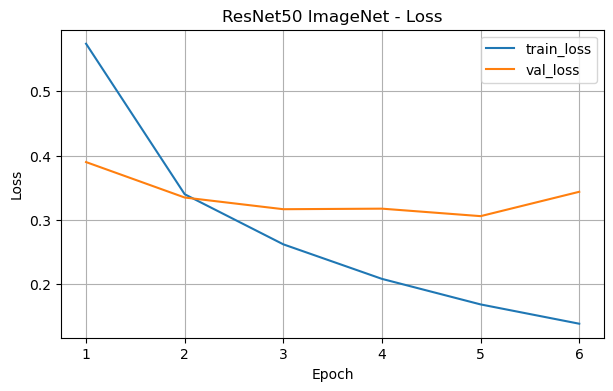

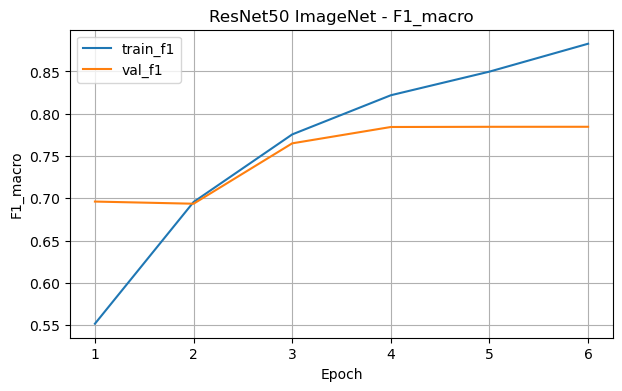

In [18]:
plot_history(history_resnet, "ResNet50 ImageNet")

In [19]:
test_loss_resnet, test_f1_resnet, y_true_resnet, y_pred_resnet = test_model(
    model_resnet,
    test_loader,
    criterion,
    device
)

print("ResNet50 test_loss:", round(test_loss_resnet, 4))
print("ResNet50 test_f1_macro:", round(test_f1_resnet, 4))
print(classification_report(y_true_resnet, y_pred_resnet, target_names=classes, digits=4))

  0%|          | 0/282 [00:00<?, ?it/s]

ResNet50 test_loss: 0.3344
ResNet50 test_f1_macro: 0.7843
              precision    recall  f1-score   support

       Beige     0.4624    0.8889    0.6084        90
       Black     0.9613    0.8664    0.9114      2148
        Blue     0.8890    0.9309    0.9094      1273
      Bronze     0.5200    0.5306    0.5253        49
       Brown     0.5818    0.7007    0.6358       137
        Gold     0.6316    0.3750    0.4706        32
       Green     0.8785    0.8103    0.8430       116
        Grey     0.8298    0.8783    0.8533      1421
      Orange     0.8701    0.7976    0.8323        84
        Pink     0.6875    0.8462    0.7586        13
      Purple     0.4792    0.8519    0.6133        54
         Red     0.9798    0.9573    0.9685       914
      Silver     0.9217    0.8782    0.8994      1166
       White     0.9692    0.9823    0.9757      1410
      Yellow     0.9694    0.9500    0.9596       100

    accuracy                         0.8999      9007
   macro avg     0.775

In [27]:
clip_backbone, _, _ = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="laion2b_s34b_b79k"
)
class CLIPColorClassifier(nn.Module):
    def __init__(self, backbone, num_classes):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Linear(backbone.visual.output_dim, num_classes)

    def forward(self, x):
        features = self.backbone.encode_image(x)
        features = features.float()
        return self.head(features)

model_clip = CLIPColorClassifier(clip_backbone, num_classes).to(device)
optimizer_clip = optim.AdamW(model_clip.parameters(), lr=1e-5, weight_decay=WEIGHT_DECAY)

In [28]:
model_clip, history_clip, best_val_f1_clip = fit_model(
    model_clip,
    clip_train_loader,
    clip_val_loader,
    criterion,
    optimizer_clip,
    device,
    EPOCHS_FINETUNE
)

  0%|          | 0/1314 [00:00<?, ?it/s]

  0%|          | 0/282 [00:00<?, ?it/s]

Epoch 1/6 | train_loss=0.5711 | train_f1=0.5490 | val_loss=0.4461 | val_f1=0.6004


  0%|          | 0/1314 [00:00<?, ?it/s]

  0%|          | 0/282 [00:00<?, ?it/s]

...

  0%|          | 0/1314 [00:00<?, ?it/s]

  0%|          | 0/282 [00:00<?, ?it/s]

Epoch 3/6 | train_loss=0.2969 | train_f1=0.7660 | val_loss=0.3829 | val_f1=0.7135


  0%|          | 0/1314 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [29]:
plot_history(history_clip, "CLIP ViT-B/32")

NameError: name 'history_clip' is not defined

In [ ]:
epochs = [1, 2, 3]

train_loss = [0.5711, 0.3700, 0.2969]
val_loss   = [0.4461, 0.4018, 0.3829]

train_f1 = [0.5490, 0.6907, 0.7660]
val_f1   = [0.6004, 0.6739, 0.7135]

plt.figure()
plt.plot(epochs, train_loss, marker='o', label='train_loss')
plt.plot(epochs, val_loss, marker='o', label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss по эпохам')
plt.legend()
plt.grid()

plt.figure()
plt.plot(epochs, train_f1, marker='o', label='train_f1')
plt.plot(epochs, val_f1, marker='o', label='val_f1')
plt.xlabel('Epoch')
plt.ylabel('F1')
plt.title('F1_macro по эпохам')
plt.legend()
plt.grid()

plt.show()

In [30]:
test_loss_clip, test_f1_clip, y_true_clip, y_pred_clip = test_model(
    model_clip,
    clip_test_loader,
    criterion,
    device
)

print("CLIP test_loss:", round(test_loss_clip, 4))
print("CLIP test_f1_macro:", round(test_f1_clip, 4))
print(classification_report(y_true_clip, y_pred_clip, target_names=classes, digits=4))

  0%|          | 0/282 [00:00<?, ?it/s]

CLIP test_loss: 0.394
CLIP test_f1_macro: 0.7178
              precision    recall  f1-score   support

       Beige     0.6447    0.5444    0.5904        90
       Black     0.9242    0.8738    0.8983      2148
        Blue     0.8042    0.9293    0.8622      1273
      Bronze     0.5625    0.1837    0.2769        49
       Brown     0.7009    0.5985    0.6457       137
        Gold     0.7500    0.0938    0.1667        32
       Green     0.9333    0.7241    0.8155       116
        Grey     0.8455    0.7551    0.7978      1421
      Orange     0.9524    0.4762    0.6349        84
        Pink     0.8333    0.7692    0.8000        13
      Purple     0.9565    0.4074    0.5714        54
         Red     0.9467    0.9902    0.9679       914
      Silver     0.8238    0.8979    0.8593      1166
       White     0.9081    0.9879    0.9463      1410
      Yellow     0.9579    0.9100    0.9333       100

    accuracy                         0.8735      9007
   macro avg     0.8363    0.67

In [31]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = CustomCNN(num_classes).to(device)
optimizer_scratch = optim.AdamW(model_scratch.parameters(), lr=LR_SCRATCH, weight_decay=WEIGHT_DECAY)

In [ ]:
model_scratch, history_scratch, best_val_f1_scratch = fit_model(
    model_scratch,
    train_loader,
    val_loader,
    criterion,
    optimizer_scratch,
    device,
    3
)

  0%|          | 0/1314 [00:00<?, ?it/s]

  0%|          | 0/282 [00:00<?, ?it/s]

Epoch 1/3 | train_loss=1.1657 | train_f1=0.3026 | val_loss=0.8993 | val_f1=0.3563


  0%|          | 0/1314 [00:00<?, ?it/s]

In [ ]:
plot_history(history_scratch, "Custom CNN")

In [ ]:
test_loss_scratch, test_f1_scratch, y_true_scratch, y_pred_scratch = test_model(
    model_scratch,
    test_loader,
    criterion,
    device
)

print("Custom CNN test_loss:", round(test_loss_scratch, 4))
print("Custom CNN test_f1_macro:", round(test_f1_scratch, 4))
print(classification_report(y_true_scratch, y_pred_scratch, target_names=classes, digits=4))

In [ ]:
results = pd.DataFrame({
    "model": [
        "ResNet50 ImageNet",
        "CLIP ViT-B/32",
        "Custom CNN"
    ],
    "best_val_f1": [
        best_val_f1_resnet,
        best_val_f1_clip,
        best_val_f1_scratch
    ],
    "test_f1_macro": [
        test_f1_resnet,
        test_f1_clip,
        test_f1_scratch
    ]
}).sort_values("test_f1_macro", ascending=False).reset_index(drop=True)

results

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(results["model"], results["test_f1_macro"])
plt.title("Сравнение моделей по F1_macro")
plt.ylabel("F1_macro")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.grid(axis="y")
plt.show()

In [ ]:
best_model_name = results.iloc[0]["model"]

if best_model_name == "ResNet50 ImageNet":
    y_true_best, y_pred_best = y_true_resnet, y_pred_resnet
elif best_model_name == "CLIP ViT-B/32":
    y_true_best, y_pred_best = y_true_clip, y_pred_clip
else:
    y_true_best, y_pred_best = y_true_scratch, y_pred_scratch

cm = confusion_matrix(y_true_best, y_pred_best)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.colorbar()
plt.xticks(range(num_classes), classes, rotation=90)
plt.yticks(range(num_classes), classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [ ]:
best_row = results.iloc[0]
worst_row = results.iloc[-1]

print("Лучшая модель:", best_row["model"])
print("F1_macro на тесте:", round(best_row["test_f1_macro"], 4))
print()
print("Худшая модель:", worst_row["model"])
print("F1_macro на тесте:", round(worst_row["test_f1_macro"], 4))

Вывод
Модель, обученная с нуля, показала наихудший результат (F1_macro ≈ 0.35–0.5), что объясняется отсутствием предобученных признаков. Предобученные модели (ResNet и CLIP) продемонстрировали значительно лучшее качество, что подтверждает эффективность transfer learning.